# Sweep Results Diagnostics

This notebook analyzes the HDF5 results from the Toy Models of Superposition experiment sweep.

**Fractional Dimensionality Interpretation:**
- D_i = M_ii² / (M²)_ii where M = W^T W
- D_i represents **d/p** = dimension / number of features sharing that subspace
- D_i ≈ 0.5 → digon (2 features in 1D)
- D_i ≈ 0.67 → triangle (3 features in 2D)  
- D_i ≈ 0.75 → tetrahedron (4 features in 3D)
- D_i ≈ 1.0 → orthogonal (feature owns its dimension)

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load Results and Check Completion

In [4]:
RESULTS_DIR = Path('results')

# Expected experiment grid (from sweep.py)
N_FEATURES = 1024
M_VALUES = np.logspace(np.log10(16), np.log10(1024), 20).astype(int)
M_VALUES = sorted(set(M_VALUES))

K_VALUES = np.logspace(0, 2, 30)
SPARSITY_VALUES = 1.0 - 1.0 / K_VALUES
SEEDS = [0, 1, 2]

expected_total = len(M_VALUES) * len(SPARSITY_VALUES) * len(SEEDS)
print(f"Expected: {len(M_VALUES)} m-values x {len(SPARSITY_VALUES)} sparsities x {len(SEEDS)} seeds = {expected_total} experiments")
print(f"m_hidden values: {list(M_VALUES)}")

Expected: 20 m-values x 30 sparsities x 3 seeds = 1800 experiments
m_hidden values: [16, 19, 24, 30, 38, 47, 59, 74, 92, 114, 142, 177, 221, 275, 342, 426, 531, 660, 822, 1024]


In [5]:
h5_files = list(RESULTS_DIR.glob('*.h5'))
print(f"Found {len(h5_files)} h5 files ({100*len(h5_files)/expected_total:.1f}% complete)")

Found 550 h5 files (30.6% complete)


In [6]:
def parse_filename(fname):
    name = fname.stem
    parts = name.split('_')
    return {
        'n': int(parts[0][1:]),
        'm': int(parts[1][1:]),
        's': float(parts[2][1:]),
        'seed': int(parts[3][4:])
    }

parsed_files = []
for f in h5_files:
    try:
        parsed_files.append({'path': f, **parse_filename(f)})
    except Exception as e:
        print(f"Error parsing {f}: {e}")

print(f"Parsed {len(parsed_files)} files")

Parsed 550 files


## 2. Completion Heatmap

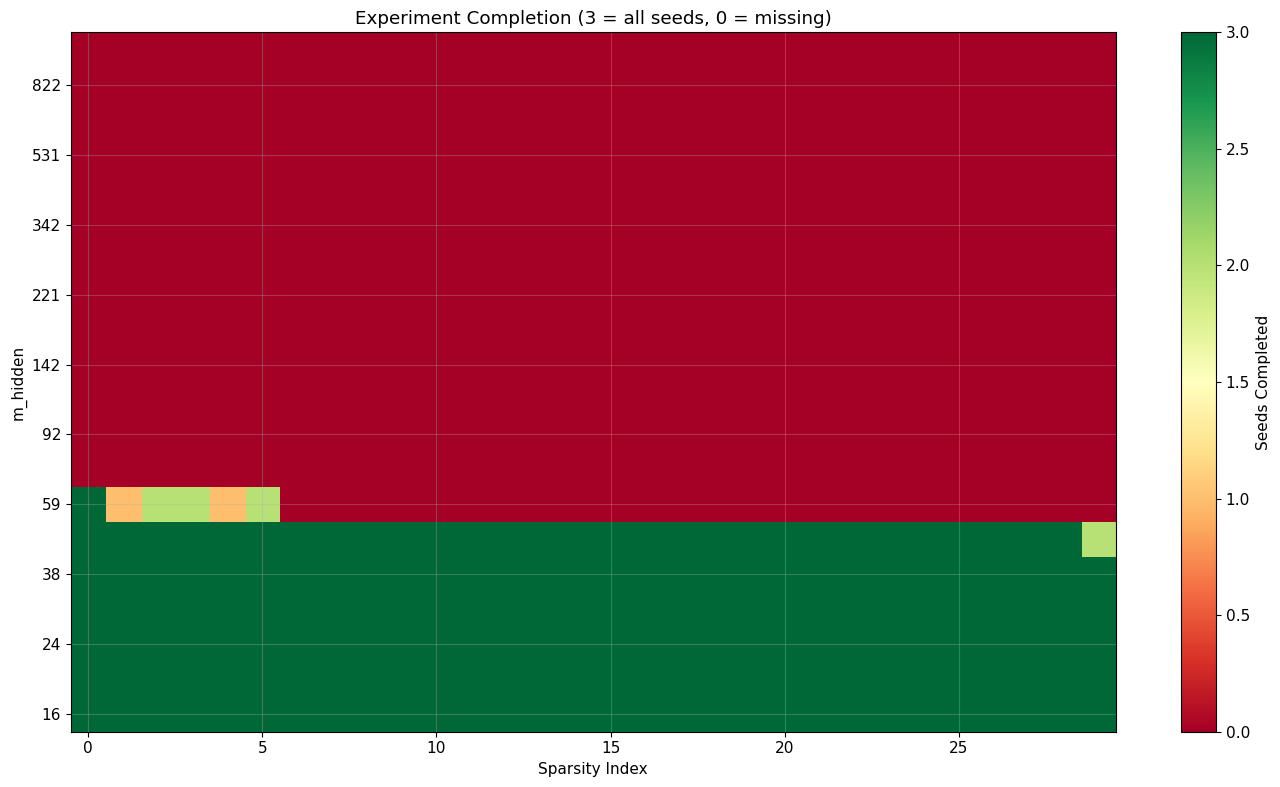

Complete: 180, Partial: 6, Missing: 414


In [7]:
completion_map = defaultdict(set)
for pf in parsed_files:
    key = (pf['m'], round(pf['s'], 6))
    completion_map[key].add(pf['seed'])

m_unique = sorted(set(M_VALUES))
s_unique = sorted(SPARSITY_VALUES)

completion_matrix = np.zeros((len(m_unique), len(s_unique)))
for i, m in enumerate(m_unique):
    for j, s in enumerate(s_unique):
        key = (int(m), round(s, 6))
        completion_matrix[i, j] = len(completion_map.get(key, set()))

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(completion_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=3, origin='lower')
ax.set_xlabel('Sparsity Index')
ax.set_ylabel('m_hidden')
ax.set_title('Experiment Completion (3 = all seeds, 0 = missing)')
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])
plt.colorbar(im, ax=ax, label='Seeds Completed')
plt.tight_layout()
plt.show()

fully_complete = (completion_matrix == 3).sum()
partially_complete = ((completion_matrix > 0) & (completion_matrix < 3)).sum()
missing = (completion_matrix == 0).sum()
print(f"Complete: {fully_complete}, Partial: {partially_complete}, Missing: {missing}")

## 3. Validate and Load Data

In [8]:
def validate_h5_file(filepath):
    issues = []
    try:
        with h5py.File(filepath, 'r') as f:
            for attr in ['n_features', 'm_hidden', 'sparsity', 'seed']:
                if attr not in f.attrs:
                    issues.append(f"Missing: {attr}")
            for ds in ['fractional_dims', 'losses']:
                if ds not in f:
                    issues.append(f"Missing: {ds}")
            if 'fractional_dims' in f:
                fd = f['fractional_dims'][:]
                if np.isnan(fd).any() or np.isinf(fd).any():
                    issues.append("NaN/Inf in fractional_dims")
    except Exception as e:
        issues.append(str(e))
    return issues

corrupted = []
for pf in parsed_files:
    issues = validate_h5_file(pf['path'])
    if issues:
        corrupted.append((pf['path'], issues))

print(f"Valid: {len(parsed_files) - len(corrupted)}, Corrupted: {len(corrupted)}")
if corrupted:
    for path, issues in corrupted[:5]:
        print(f"  {path.name}: {issues}")

Valid: 550, Corrupted: 0


In [9]:
all_data = []
corrupted_paths = set(c[0] for c in corrupted)

for pf in parsed_files:
    if pf['path'] in corrupted_paths:
        continue
    try:
        with h5py.File(pf['path'], 'r') as f:
            all_data.append({
                'path': pf['path'],
                'n': int(f.attrs['n_features']),
                'm': int(f.attrs['m_hidden']),
                'sparsity': float(f.attrs['sparsity']),
                'seed': int(f.attrs['seed']),
                'checkpoint_steps': f['checkpoint_steps'][:],
                'fractional_dims': f['fractional_dims'][:],
                'feature_norms': f['feature_norms'][:],
                'losses': f['losses'][:]
            })
    except Exception as e:
        print(f"Error: {pf['path']}: {e}")

print(f"Loaded {len(all_data)} experiments")

Loaded 550 experiments


## 4. Fractional Dimensionality (d/p) Distribution

D_i is the fractional dimensionality of feature i:
- X-axis: D_i values (= d/p, the dimension per feature)
- Y-axis: Number of features with that D_i value

Reference configurations:
- Digon: D_i = 0.5 (2 features in 1D)
- Triangle: D_i = 0.667 (3 features in 2D)
- Tetrahedron: D_i = 0.75 (4 features in 3D)

In [10]:
# Collect fractional dimensionality from final checkpoint of each experiment
# D_i values should typically be in range [0, 1] with some possibly > 1

N_BINS = 100
D_MIN, D_MAX = 0.0, 1.5  # D_i range
bin_edges = np.linspace(D_MIN, D_MAX, N_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Accumulate histogram
global_hist = np.zeros(N_BINS, dtype=np.int64)
all_D_stats = []
metadata = []

print("Computing D_i distributions...")
for i, data in enumerate(all_data):
    # Get final checkpoint D_i values
    D_i = data['fractional_dims'][-1]  # shape: (n_features,)
    
    # Histogram
    D_clipped = np.clip(D_i, D_MIN, D_MAX - 1e-9)
    hist, _ = np.histogram(D_clipped, bins=bin_edges)
    global_hist += hist
    
    # Store stats
    all_D_stats.append({
        'mean': np.mean(D_i),
        'median': np.median(D_i),
        'std': np.std(D_i),
        'min': np.min(D_i),
        'max': np.max(D_i),
        'raw': D_i
    })
    metadata.append({'m': data['m'], 'sparsity': data['sparsity'], 'seed': data['seed']})

total_features = global_hist.sum()
print(f"Total features analyzed: {total_features:,} ({len(all_data)} experiments x {N_FEATURES} features)")

Computing D_i distributions...
Total features analyzed: 563,200 (550 experiments x 1024 features)


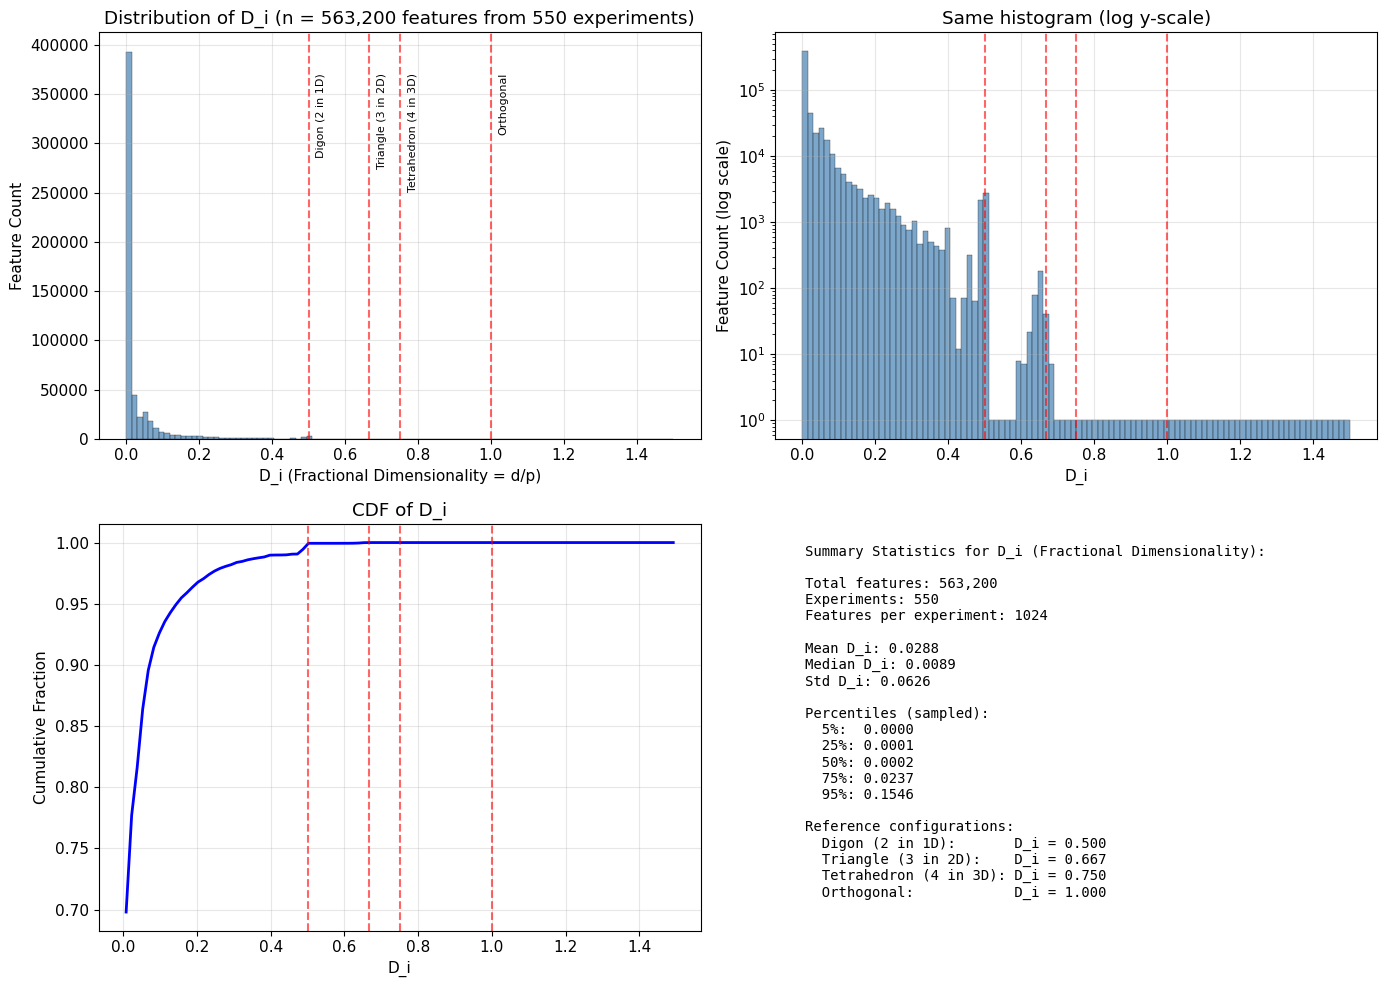

In [15]:
# Reference simplex configurations
simplex_configs = {
    'Digon (2 in 1D)': 1/2,
    'Triangle (3 in 2D)': 2/3,
    'Tetrahedron (4 in 3D)': 3/4,
    'Orthogonal': 1.0
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Main histogram
ax = axes[0, 0]
ax.bar(bin_centers, global_hist, width=bin_edges[1]-bin_edges[0], 
       alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
for name, val in simplex_configs.items():
    ax.axvline(x=val, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(val + 0.02, ax.get_ylim()[1] * 0.9, name, rotation=90, fontsize=8, va='top')
ax.set_xlabel('D_i (Fractional Dimensionality = d/p)')
ax.set_ylabel('Feature Count')
ax.set_title(f'Distribution of D_i (n = {total_features:,} features from {len(all_data)} experiments)')

# 2. Log scale
ax = axes[0, 1]
ax.bar(bin_centers, global_hist + 1, width=bin_edges[1]-bin_edges[0], 
       alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
for val in simplex_configs.values():
    ax.axvline(x=val, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('D_i')
ax.set_ylabel('Feature Count (log scale)')
ax.set_title('Same histogram (log y-scale)')
ax.set_yscale('log')

# 3. CDF
ax = axes[1, 0]
cdf = np.cumsum(global_hist) / total_features
ax.plot(bin_centers, cdf, 'b-', linewidth=2)
for name, val in simplex_configs.items():
    ax.axvline(x=val, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('D_i')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('CDF of D_i')

# 4. Statistics
ax = axes[1, 1]
ax.axis('off')

# Sample for percentiles
sampled_D = np.concatenate([s['raw'][::10] for s in all_D_stats])

stats_text = f"""Summary Statistics for D_i (Fractional Dimensionality):

Total features: {total_features:,}
Experiments: {len(all_data)}
Features per experiment: {N_FEATURES}

Mean D_i: {np.mean([s['mean'] for s in all_D_stats]):.4f}
Median D_i: {np.mean([s['median'] for s in all_D_stats]):.4f}
Std D_i: {np.mean([s['std'] for s in all_D_stats]):.4f}

Percentiles (sampled):
  5%:  {np.percentile(sampled_D, 5):.4f}
  25%: {np.percentile(sampled_D, 25):.4f}
  50%: {np.percentile(sampled_D, 50):.4f}
  75%: {np.percentile(sampled_D, 75):.4f}
  95%: {np.percentile(sampled_D, 95):.4f}

Reference configurations:
  Digon (2 in 1D):       D_i = 0.500
  Triangle (3 in 2D):    D_i = 0.667
  Tetrahedron (4 in 3D): D_i = 0.750
  Orthogonal:            D_i = 1.000
"""
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

## 5. D_i Distribution by Sparsity

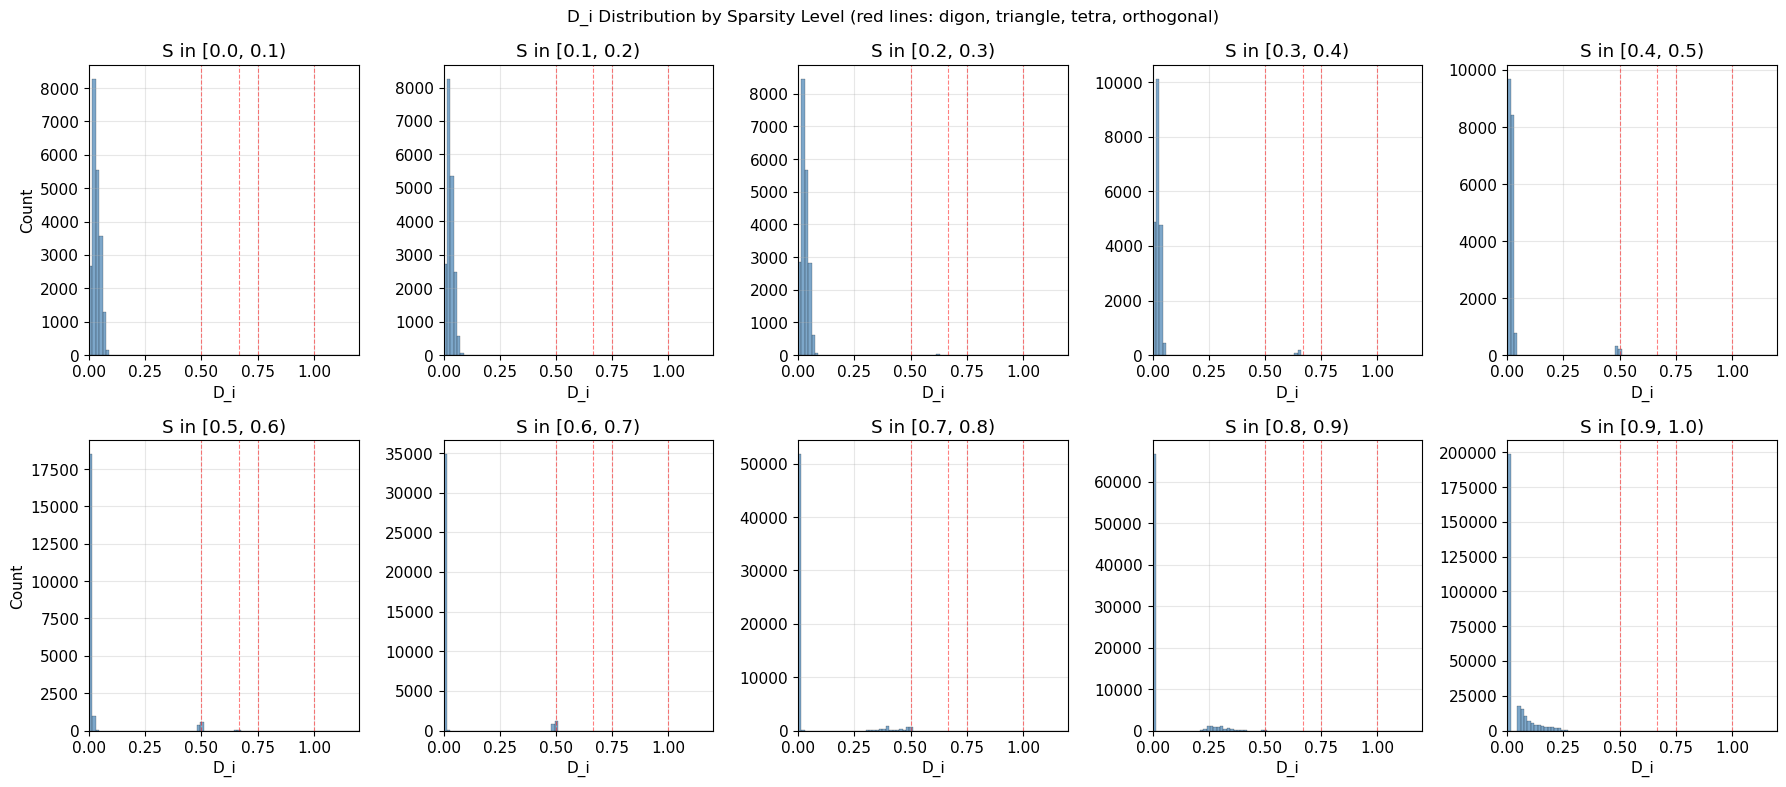

In [14]:
sparsity_bins = np.linspace(0, 1, 11)
sparsity_hists = {i: np.zeros(N_BINS, dtype=np.int64) for i in range(10)}

for stats, meta in zip(all_D_stats, metadata):
    s = meta['sparsity']
    bin_idx = min(int(s * 10), 9)
    D_clipped = np.clip(stats['raw'], D_MIN, D_MAX - 1e-9)
    hist, _ = np.histogram(D_clipped, bins=bin_edges)
    sparsity_hists[bin_idx] += hist

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    hist = sparsity_hists[i]
    if hist.sum() > 0:
        ax.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], 
               alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.2)
        for val in [0.5, 2/3, 0.75, 1.0]:
            ax.axvline(x=val, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_title(f'S in [{sparsity_bins[i]:.1f}, {sparsity_bins[i+1]:.1f})')
    ax.set_xlabel('D_i')
    ax.set_xlim(0, 1.2)
    if i % 5 == 0:
        ax.set_ylabel('Count')

plt.suptitle('D_i Distribution by Sparsity Level (red lines: digon, triangle, tetra, orthogonal)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. D_i Distribution by m_hidden

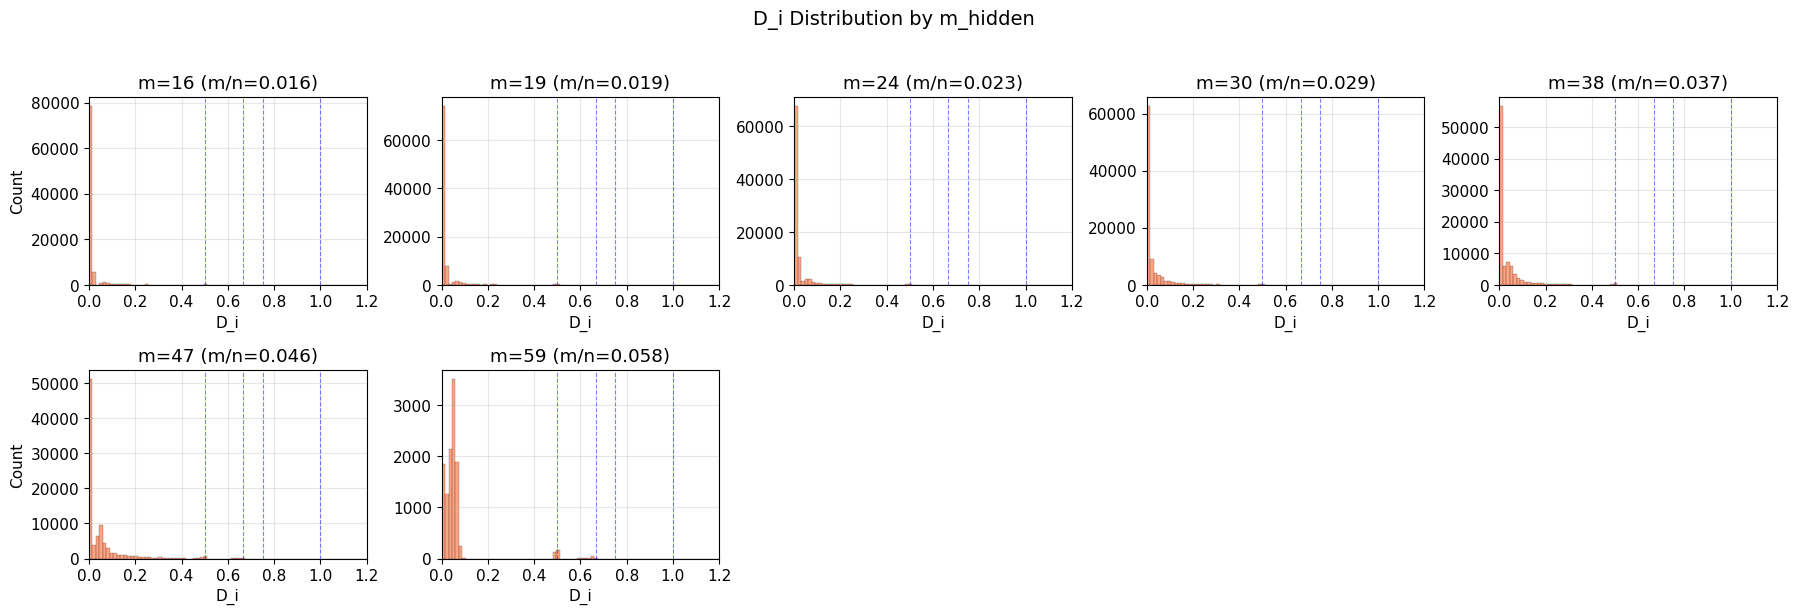

In [11]:
m_hists = defaultdict(lambda: np.zeros(N_BINS, dtype=np.int64))

for stats, meta in zip(all_D_stats, metadata):
    m = meta['m']
    D_clipped = np.clip(stats['raw'], D_MIN, D_MAX - 1e-9)
    hist, _ = np.histogram(D_clipped, bins=bin_edges)
    m_hists[m] += hist

available_m = sorted(m_hists.keys())
n_plots = len(available_m)
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows))
axes = axes.flatten() if n_rows > 1 else list(axes)

for idx, m in enumerate(available_m):
    ax = axes[idx]
    hist = m_hists[m]
    if hist.sum() > 0:
        ax.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], 
               alpha=0.7, color='coral', edgecolor='black', linewidth=0.2)
        for val in [0.5, 2/3, 0.75, 1.0]:
            ax.axvline(x=val, color='blue', linestyle='--', alpha=0.5, linewidth=0.8)
    compression = m / N_FEATURES
    ax.set_title(f'm={m} (m/n={compression:.3f})')
    ax.set_xlabel('D_i')
    ax.set_xlim(0, 1.2)
    if idx % n_cols == 0:
        ax.set_ylabel('Count')

for idx in range(len(available_m), len(axes)):
    axes[idx].axis('off')

plt.suptitle('D_i Distribution by m_hidden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Mean D_i Heatmap (m vs Sparsity)

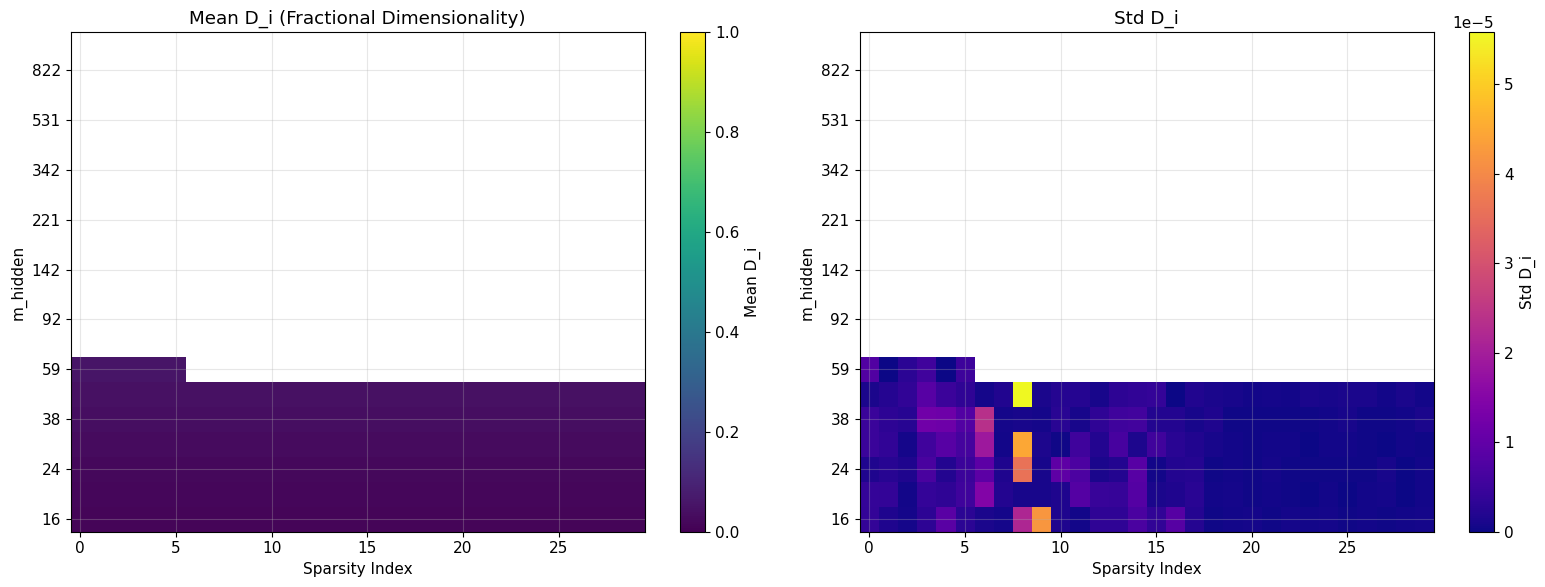

In [12]:
mean_D_matrix = np.full((len(m_unique), len(s_unique)), np.nan)
std_D_matrix = np.full((len(m_unique), len(s_unique)), np.nan)

ms_groups = defaultdict(list)
for stats, meta in zip(all_D_stats, metadata):
    ms_groups[(meta['m'], round(meta['sparsity'], 6))].append(stats)

for i, m in enumerate(m_unique):
    for j, s in enumerate(s_unique):
        key = (int(m), round(s, 6))
        if key in ms_groups:
            means = [stat['mean'] for stat in ms_groups[key]]
            mean_D_matrix[i, j] = np.mean(means)
            std_D_matrix[i, j] = np.std(means)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.imshow(mean_D_matrix, aspect='auto', cmap='viridis', origin='lower', vmin=0, vmax=1)
ax.set_xlabel('Sparsity Index')
ax.set_ylabel('m_hidden')
ax.set_title('Mean D_i (Fractional Dimensionality)')
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])
plt.colorbar(im, ax=ax, label='Mean D_i')

ax = axes[1]
im = ax.imshow(std_D_matrix, aspect='auto', cmap='plasma', origin='lower')
ax.set_xlabel('Sparsity Index')
ax.set_ylabel('m_hidden')
ax.set_title('Std D_i')
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])
plt.colorbar(im, ax=ax, label='Std D_i')

plt.tight_layout()
plt.show()

## 8. Loss Convergence

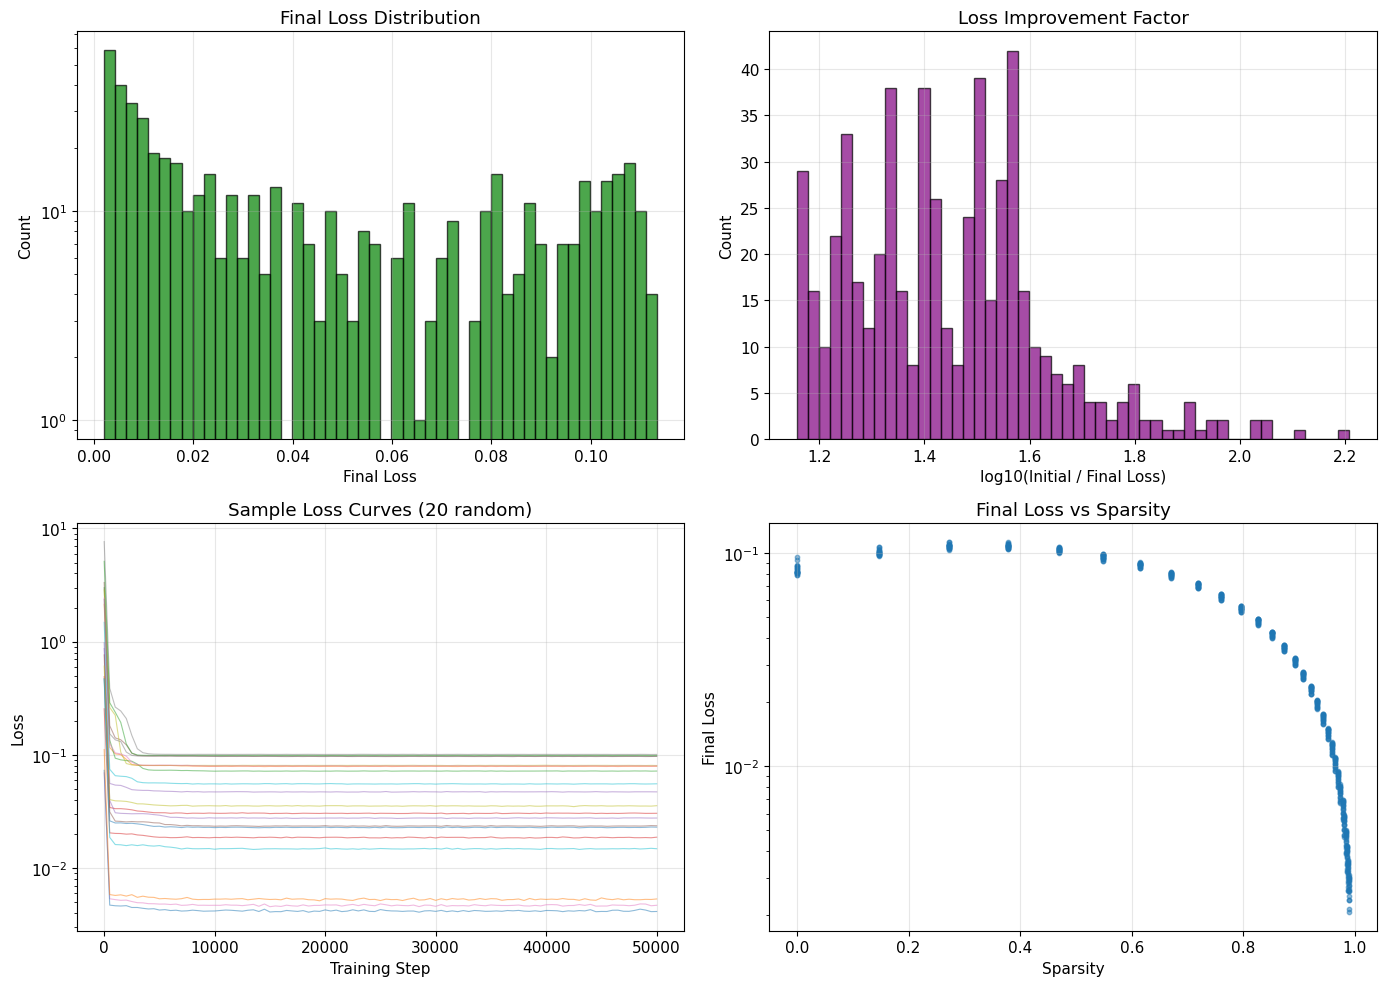

Loss stats: mean=0.043803, median=0.030807, max=0.113247


In [13]:
final_losses = np.array([data['losses'][-1] for data in all_data])
initial_losses = np.array([data['losses'][0] for data in all_data])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(final_losses, bins=50, alpha=0.7, color='green', edgecolor='black')
ax.set_xlabel('Final Loss')
ax.set_ylabel('Count')
ax.set_title('Final Loss Distribution')
ax.set_yscale('log')

ax = axes[0, 1]
improvement = initial_losses / (final_losses + 1e-10)
ax.hist(np.log10(improvement + 1), bins=50, alpha=0.7, color='purple', edgecolor='black')
ax.set_xlabel('log10(Initial / Final Loss)')
ax.set_ylabel('Count')
ax.set_title('Loss Improvement Factor')

ax = axes[1, 0]
sample_idx = np.random.choice(len(all_data), min(20, len(all_data)), replace=False)
for idx in sample_idx:
    data = all_data[idx]
    ax.plot(data['checkpoint_steps'], data['losses'], alpha=0.5, linewidth=0.8)
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Sample Loss Curves (20 random)')
ax.set_yscale('log')

ax = axes[1, 1]
sparsities = [meta['sparsity'] for meta in metadata]
ax.scatter(sparsities, final_losses, alpha=0.5, s=10)
ax.set_xlabel('Sparsity')
ax.set_ylabel('Final Loss')
ax.set_title('Final Loss vs Sparsity')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Loss stats: mean={np.mean(final_losses):.6f}, median={np.median(final_losses):.6f}, max={np.max(final_losses):.6f}")

## 9. Feature Norms

In [ ]:
norm_bins = np.linspace(0, 2, 101)
norm_hist = np.zeros(100, dtype=np.int64)

for data in all_data:
    final_norms = data['feature_norms'][-1]
    clipped = np.clip(final_norms, 0, 2 - 1e-9)
    h, _ = np.histogram(clipped, bins=norm_bins)
    norm_hist += h

norm_centers = (norm_bins[:-1] + norm_bins[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(norm_centers, norm_hist, width=norm_bins[1]-norm_bins[0], 
       alpha=0.7, color='teal', edgecolor='black', linewidth=0.2)
ax.set_xlabel('||W_i||^2')
ax.set_ylabel('Count')
ax.set_title('Feature Norm Distribution')

ax = axes[1]
ax.bar(norm_centers, norm_hist + 1, width=norm_bins[1]-norm_bins[0], 
       alpha=0.7, color='teal', edgecolor='black', linewidth=0.2)
ax.set_xlabel('||W_i||^2')
ax.set_ylabel('Count (log)')
ax.set_title('Log scale')
ax.set_yscale('log')

ax = axes[2]
sample_idx = np.random.choice(len(all_data), min(10, len(all_data)), replace=False)
for idx in sample_idx:
    norms = all_data[idx]['feature_norms'][-1]
    D_i = all_D_stats[idx]['raw']
    ax.scatter(norms, D_i, alpha=0.3, s=5)
ax.set_xlabel('||W_i||^2')
ax.set_ylabel('D_i')
ax.set_title('D_i vs Feature Norm')

plt.tight_layout()
plt.show()

dead_features = norm_hist[0]
print(f"Near-zero norm features: {dead_features} ({100*dead_features/norm_hist.sum():.2f}%)")

## 10. D_i Evolution During Training

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

def select_diverse(all_data, metadata, n=6):
    seen = set()
    selected = []
    indices = list(range(len(all_data)))
    np.random.shuffle(indices)
    for idx in indices:
        key = (metadata[idx]['m'], round(metadata[idx]['sparsity'], 2))
        if key not in seen:
            seen.add(key)
            selected.append(idx)
            if len(selected) >= n:
                break
    return selected

selected = select_diverse(all_data, metadata, n=6)

for plot_idx, data_idx in enumerate(selected):
    ax = axes.flatten()[plot_idx]
    data = all_data[data_idx]
    meta = metadata[data_idx]
    
    # D_i over time
    D_all = data['fractional_dims']  # (n_checkpoints, n_features)
    mean_D = np.mean(D_all, axis=1)
    std_D = np.std(D_all, axis=1)
    
    ax.fill_between(data['checkpoint_steps'], mean_D - std_D, mean_D + std_D, alpha=0.3)
    ax.plot(data['checkpoint_steps'], mean_D, 'b-', linewidth=1.5)
    
    # Reference lines
    for val, name in [(0.5, 'digon'), (2/3, 'tri'), (0.75, 'tetra'), (1.0, 'orth')]:
        ax.axhline(y=val, color='red', linestyle=':', alpha=0.4, linewidth=0.8)
    
    ax.set_xlabel('Step')
    ax.set_ylabel('Mean D_i')
    ax.set_title(f'm={meta["m"]}, S={meta["sparsity"]:.2f}')
    ax.set_ylim(0, 1.2)

plt.suptitle('Evolution of Mean D_i During Training (shaded = +/- 1 std)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Summary

In [ ]:
print("=" * 70)
print("SWEEP DIAGNOSTICS SUMMARY")
print("=" * 70)
print(f"\nCOMPLETION: {len(h5_files)}/{expected_total} ({100*len(h5_files)/expected_total:.1f}%)")
print(f"  Valid files: {len(all_data)}")
print(f"  Corrupted: {len(corrupted)}")
print(f"\nFRACTIONAL DIMENSIONALITY (D_i = d/p):")
print(f"  Mean D_i: {np.mean([s['mean'] for s in all_D_stats]):.4f}")
print(f"  Median D_i: {np.mean([s['median'] for s in all_D_stats]):.4f}")
print(f"\nLOSS:")
print(f"  Mean final: {np.mean(final_losses):.6f}")
print(f"  Median final: {np.median(final_losses):.6f}")
print(f"\nFEATURES:")
print(f"  Near-zero norm: {dead_features} ({100*dead_features/norm_hist.sum():.2f}%)")
print("=" * 70)